# August 2026 mobile marketing lift — candidates from the UAC + Meta query

Builds the August `m` overlay curve from the new **UAC + Meta Android** query, which replaced
the marketing team's hand-delivered spreadsheet this cycle.

## The source change

Previous cycles consumed a CSV with a `Total Paid DAU` column. The new query returns **four
presentation lines** — UAC actual/forecast and UAC+Meta actual/forecast — because paid
acquisition now runs on two channels. The Meta columns are **cumulative** (`uac_v + meta_v`),
so the combined series is `COALESCE(uac_meta_*, uac_*)`, *not* a sum of the two pairs.
`[load-source-query]` asserts this on every overlapping week rather than trusting the query's
header comment.

Meta begins 2026-05-04 in 8 countries and is treated as **fully incremental** (user decision,
2026-07-30). It is 2.3% of combined paid DAU at year end.

## Method: anchor-and-subtract

    lift(d) = paid_dau(d) − paid_dau(2026-03-30),  clipped to 0 before the anchor

Restores the method from `research/marketing-lift/v2-real-data/02_forecast_projection.ipynb`,
cell `[anchor-at-launch]`, which June replaced with an empirical-gap hybrid. The anchor
subtraction is what makes the series incremental: it removes the pre-existing paid base
(~922K) that Prophet already sees in history.

Two properties worth noting. It is **memoryless** — each delivery re-derives the whole curve,
with no dependence on any prior cycle's artifact, unlike the June→July→August chain that
stacked two cycles of outlook deltas onto a single 45-day measurement. And it is **smooth**,
since it comes from weekly source data interpolated to daily, where July's wired curve carries
raw day-of-week noise into the training rows it is subtracted from.

## Two candidates, one open decision

The query offers two metric bases and they differ at Dec-15 by ~152K. `[basis-comparison]`
shows why the difference is structural rather than cosmetic. Both are exported by
`[export-curves]` as overlay-ready parquets; the next step is a test-apply through the
bidirectional `m` machinery.

## Scope

The curve spans **2026-02-01 → 2026-12-31**; it is *not* extended into 2027 (user decision,
2026-07-30: 2027 is out of scope). Nothing here is wired — `marketing.json` still points at
July's carried-forward curve.


In [1]:
# [setup]
from pathlib import Path

import db_dtypes  # noqa: F401  — registers the `dbdate` extension dtype used by BQ parquets
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

REPO = Path.cwd()
while not (REPO / "src" / "mozaic_daily").exists():
    REPO = REPO.parent

HERE = REPO / "data-official/2026-08/marketing"
PLOTS = REPO / "data-official/2026-08/plots"
PLOTS.mkdir(parents=True, exist_ok=True)

# --- Inputs -------------------------------------------------------------------
SOURCE_QUERY_CSV = HERE / "source_data/uac_meta_paid_dau.20260730.csv"
MOBILE_BASELINE = (REPO / "data-official/2026-08/mobile_baseline_2026-07-28"
                   / "cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6_sps0.1")
RAW_ACTUALS = MOBILE_BASELINE / "mozaic_parts.raw.glean.mobile.DAU.parquet"
JULY_WIRED_LIFT = (REPO / "data-official/2026-07/marketing"
                   / "marketing_lift_model.total.2026-06-29.parquet")

# --- Dates --------------------------------------------------------------------
PARQUET_START = pd.Timestamp("2026-02-01")
PARQUET_END = pd.Timestamp("2026-12-31")     # 2027 deliberately out of scope
WEEK1_MONDAY = pd.Timestamp("2026-01-05")
CAMPAIGN_LAUNCH = pd.Timestamp("2026-04-06")
ANCHOR_DATE = pd.Timestamp("2026-03-30")     # method D anchor: last Monday pre-launch
TRAINING_END = pd.Timestamp("2026-07-27")    # August cycle trains through here
KPI_DATE = pd.Timestamp("2026-12-15")

MA_WINDOW = 28      # display MA, matches the stakeholder-facing convention
DOW_WINDOW = 7      # centered, cancels the weekly cycle exactly

# Iran is excluded from the lift on both sides: no paid spend there, and the April
# counterfactual predates Iran's native treatment (see notebook intro).
EXCLUDE_COUNTRIES = ["IR"]

# --- Plot helpers -------------------------------------------------------------
# Series here span ~450K-1.6M for paid DAU and ~11M-13M for mobile DAU. A bare
# ",.2s"/"{:.0f}M" suffix formatter collapses adjacent ticks to identical text, so
# resolution is chosen per-panel from the actual tick step.
fmt_thousands = FuncFormatter(lambda v, _: f"{v / 1e3:,.0f}K")
fmt_millions_2dp = FuncFormatter(lambda v, _: f"{v / 1e6:.2f}M")


def style_time_axis(ax, ylabel, title, yfmt=fmt_thousands, month_interval=1):
    ax.set_title(title, fontsize=11, loc="left")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.yaxis.set_major_formatter(yfmt)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=month_interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(alpha=0.25, linewidth=0.6)


def interpolate_weekly_to_daily(index, values, end=PARQUET_END):
    """Linearly interpolate weekly Monday anchors to a daily series through `end`."""
    weekly = pd.Series(values, index=pd.DatetimeIndex(index)).sort_index().astype("float64")
    daily_index = pd.date_range(weekly.index.min(), end, freq="D")
    return weekly.reindex(daily_index).interpolate(method="linear", limit_area="inside").ffill()


print(f"repo           : {REPO}")
print(f"source query   : {SOURCE_QUERY_CSV.relative_to(REPO)}  exists={SOURCE_QUERY_CSV.exists()}")
print(f"raw actuals    : {RAW_ACTUALS.relative_to(REPO)}  exists={RAW_ACTUALS.exists()}")
print(f"july wired lift: {JULY_WIRED_LIFT.relative_to(REPO)}  exists={JULY_WIRED_LIFT.exists()}")
print(f"curve span     : {PARQUET_START.date()} -> {PARQUET_END.date()}  (2027 out of scope)")


repo           : /Users/brendanwells/work/mozaic-daily
source query   : data-official/2026-08/marketing/source_data/uac_meta_paid_dau.20260730.csv  exists=True
raw actuals    : data-official/2026-08/mobile_baseline_2026-07-28/cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6_sps0.1/mozaic_parts.raw.glean.mobile.DAU.parquet  exists=True
july wired lift: data-official/2026-07/marketing/marketing_lift_model.total.2026-06-29.parquet  exists=True
curve span     : 2026-02-01 -> 2026-12-31  (2027 out of scope)


In [2]:
# [load-source-query]
# The query returns four PRESENTATION lines plus the raw components. The Meta lines are
# cumulative (uac_v + meta_v), so the combined series is COALESCE(uac_meta_*, uac_*).
# Verify that on every overlapping week instead of trusting the header comment: a silent
# change to non-cumulative Meta would otherwise double-count UAC across the whole curve.

weekly = pd.read_csv(SOURCE_QUERY_CSV, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

uac_actuals_through = pd.Timestamp(weekly["uac_actuals_through"].iloc[0])
meta_actuals_through = pd.Timestamp(weekly["meta_actuals_through"].iloc[0])

both_present = weekly.dropna(subset=["uac_raw", "meta_raw"])
presented = both_present[["uac_meta_actual", "uac_meta_forecast"]].bfill(axis=1).iloc[:, 0]
stacking_error = (both_present["uac_raw"] + both_present["meta_raw"] - presented).abs().max()
assert stacking_error < 1.0, (
    f"Meta columns are not cumulative (max error {stacking_error:,.1f}). The query's stacking "
    "convention changed; combined = COALESCE(uac_meta, uac) is no longer correct."
)

# Total Paid DAU basis (includes the draining pre-2026 UAC cohort) and the 12-month
# rolling basis (excludes it). Meta has no pre-2026 cohort, so total == rolling for Meta.
weekly["combined_total"] = weekly["uac_raw"].fillna(0) + weekly["meta_raw"].fillna(0)
weekly["combined_rolling"] = weekly["uac_raw_rolling_12mo"].fillna(0) + weekly["meta_raw"].fillna(0)

print(f"weeks              : {len(weekly)}  "
      f"{weekly.date.min().date()} -> {weekly.date.max().date()}")
print(f"UAC actuals through : {uac_actuals_through.date()}")
print(f"Meta actuals through: {meta_actuals_through.date()}  "
      f"(both precede training_end {TRAINING_END.date()})")
print(f"stacking verified   : {len(both_present)} weeks, max error {stacking_error:.3f} (rounding only)")
print(f"Meta first/last week: {weekly.loc[weekly.meta_raw.notna(), 'date'].min().date()} -> "
      f"{weekly.loc[weekly.meta_raw.notna(), 'date'].max().date()}")
print()
print("Year-end (2026-12-28) composition:")
last = weekly.iloc[-1]
print(f"  UAC total          {last.uac_raw:>12,.0f}")
print(f"  Meta               {last.meta_raw:>12,.0f}   ({last.meta_raw / last.combined_total:.1%} of combined)")
print(f"  combined total     {last.combined_total:>12,.0f}")
print(f"  combined rolling   {last.combined_rolling:>12,.0f}   "
      f"(pre-2026 drain excluded: {last.combined_total - last.combined_rolling:+,.0f})")


weeks              : 52  2026-01-05 -> 2026-12-28
UAC actuals through : 2026-07-20
Meta actuals through: 2026-07-13  (both precede training_end 2026-07-27)
stacking verified   : 35 weeks, max error 0.424 (rounding only)
Meta first/last week: 2026-05-04 -> 2026-12-28

Year-end (2026-12-28) composition:
  UAC total             1,528,332
  Meta                     35,618   (2.3% of combined)
  combined total        1,563,950
  combined rolling      1,218,239   (pre-2026 drain excluded: +345,712)


In [3]:
# [method-d]
# Method D — anchor-and-subtract, faithful to
# research/marketing-lift/v2-real-data/02_forecast_projection.ipynb:[anchor-at-launch]:
#
#     lift(d) = paid_dau(d) − paid_dau(ANCHOR_DATE),  0 before the anchor
#
# The anchor subtraction is what makes this an INCREMENTAL series: it removes the
# pre-existing paid base (~922K) that Prophet already sees in history. Without it the
# curve would restate the whole paid-DAU level as campaign lift.
#
# Built on both metric bases because the choice moves Dec-15 by ~152K — the difference is
# the draining pre-2026 UAC cohort (689K -> 363K across 2026).

PAID_DAU_BASES = {
    "total": "combined_total",       # Total Paid DAU: pre-2026 cohort included
    "rolling": "combined_rolling",   # 12-month rolling: pre-2026 cohort excluded
}

paid_daily = {name: interpolate_weekly_to_daily(weekly.date, weekly[col].values)
              for name, col in PAID_DAU_BASES.items()}


def build_method_d(paid: pd.Series) -> pd.Series:
    """Re-base a daily paid-DAU series to zero at ANCHOR_DATE; pre-anchor is 0 by definition."""
    lift = paid - float(paid.loc[ANCHOR_DATE])
    lift = lift.where(lift.index >= ANCHOR_DATE, 0.0)
    lift = lift.reindex(pd.date_range(PARQUET_START, PARQUET_END, freq="D"), fill_value=0.0)
    assert lift.loc[ANCHOR_DATE] == 0.0, "lift at the anchor must be exactly 0"
    assert (lift.loc[:ANCHOR_DATE - pd.Timedelta(days=1)] == 0.0).all(), "pre-anchor lift must be 0"
    assert lift.notna().all(), "no NaN allowed in the daily lift series"
    return lift.astype("float64")


method_d = {name: build_method_d(paid) for name, paid in paid_daily.items()}

# July's wired curve is the status-quo reference every candidate is measured against.
july_wired = pd.read_parquet(JULY_WIRED_LIFT)["marketing_lift_daily"]
july_wired.index = pd.DatetimeIndex(july_wired.index)

print(f"Method D — anchor {ANCHOR_DATE.date()}\n")
print(f"{'basis':<10} {'anchor level':>14} {'Dec-15 level':>14} {'Dec-15 LIFT':>14} {'EOY LIFT':>14}")
for name, paid in paid_daily.items():
    lift = method_d[name]
    print(f"{name:<10} {paid.loc[ANCHOR_DATE]:>14,.0f} {paid.loc[KPI_DATE]:>14,.0f} "
          f"{lift.loc[KPI_DATE]:>14,.0f} {lift.loc[PARQUET_END]:>14,.0f}")

print(f"\nbasis spread at Dec-15: "
      f"{method_d['total'].loc[KPI_DATE] - method_d['rolling'].loc[KPI_DATE]:+,.0f} "
      "(the pre-2026 cohort drain)")
print("\nOriginal May-CSV run of this method: anchor 972,770 -> Dec-15 lift +490,063")
print(f"  anchor revised by {paid_daily['total'].loc[ANCHOR_DATE] - 972_770:+,.0f} "
      "(a LOWER anchor RAISES the lift, since it is subtracted)")


Method D — anchor 2026-03-30

basis        anchor level   Dec-15 level    Dec-15 LIFT       EOY LIFT
total             922,250      1,559,477        637,227        641,700
rolling           729,007      1,214,551        485,544        489,232

basis spread at Dec-15: +151,683 (the pre-2026 cohort drain)

Original May-CSV run of this method: anchor 972,770 -> Dec-15 lift +490,063
  anchor revised by -50,520 (a LOWER anchor RAISES the lift, since it is subtracted)


In [4]:
# [basis-comparison]
# The query offers two metric bases and they are not interchangeable. Writing C(d) for paid
# DAU from cohorts acquired after the anchor -- the quantity the overlay adds -- and B(d) for
# cohorts acquired at or before it:
#
#   Total basis:   L_T(d) = T(d) − T(a) = C(d) − [B(a) − B(d)]
#                  i.e. the campaign cohort minus the pre-existing base's churn.
#   Rolling basis: also loses cohorts aging out of the trailing 12-month window, on top of
#                  churn, so it sits below the Total basis.
#
#   => L_rolling < L_total
#
# The gap between them is paid DAU from cohorts older than 12 months. It GROWS, because 2025
# and early-2026 cohorts keep crossing the boundary -- the opposite direction from a drain,
# and an accounting artifact: those users did not leave, they stopped being counted.

aged_out = paid_daily["total"] - paid_daily["rolling"]
aged_out_growth = aged_out.loc[KPI_DATE] - aged_out.loc[ANCHOR_DATE]
basis_spread = method_d["total"].loc[KPI_DATE] - method_d["rolling"].loc[KPI_DATE]

assert abs(basis_spread - aged_out_growth) < 5, (
    f"basis spread {basis_spread:,.0f} should equal aged-out growth {aged_out_growth:,.0f}"
)

print("Cohorts older than 12 months (total - rolling):")
print(f"  @ anchor {ANCHOR_DATE.date()}   {aged_out.loc[ANCHOR_DATE]:>12,.0f}")
print(f"  @ Dec-15               {aged_out.loc[KPI_DATE]:>12,.0f}")
print(f"  growth                 {aged_out_growth:>+12,.0f}   <- what the rolling basis omits")
print(f"  equals the lift spread exactly: {basis_spread:+,.0f}")
print()
print(f"{'basis':<10} {'Dec-15 lift':>14} {'EOY lift':>14}")
for name in ("total", "rolling"):
    print(f"{name:<10} {method_d[name].loc[KPI_DATE]:>14,.0f} {method_d[name].loc[PARQUET_END]:>14,.0f}")
print(f"\nJuly wired (status quo): {float(july_wired.loc[KPI_DATE]):,.0f}")


Cohorts older than 12 months (total - rolling):
  @ anchor 2026-03-30        193,243
  @ Dec-15                    344,927
  growth                     +151,683   <- what the rolling basis omits
  equals the lift spread exactly: +151,683

basis         Dec-15 lift       EOY lift
total             637,227        641,700
rolling           485,544        489,232

July wired (status quo): 778,880


In [5]:
# [export-curves]
# Write both candidate curves as overlay-ready parquets + sidecar metas. Schema must match
# the wired July curve exactly, since the `m` applier reads them interchangeably.

import hashlib
import json
import subprocess
from datetime import datetime, timezone

FORECAST_START = "2026-07-28"
reference_schema = pd.read_parquet(JULY_WIRED_LIFT)
git_hash = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO).decode().strip()


def export_curve(basis: str) -> Path:
    """Write one lift curve + sidecar meta; returns the parquet path."""
    lift = method_d[basis]
    export_df = pd.DataFrame({
        "marketing_lift_daily": lift.astype("float64"),
        "marketing_lift_ma": lift.rolling(MA_WINDOW, min_periods=14).mean().astype("float64"),
    })
    export_df.index.name = "target_date"
    export_df.index = pd.DatetimeIndex(export_df.index).normalize()

    assert list(export_df.columns) == list(reference_schema.columns), "column mismatch vs wired curve"
    assert export_df.dtypes.to_dict() == reference_schema.dtypes.to_dict(), "dtype mismatch vs wired curve"
    assert export_df.index.is_unique and export_df.index.is_monotonic_increasing
    assert export_df.index.min() == PARQUET_START and export_df.index.max() == PARQUET_END

    out_parquet = HERE / f"marketing_lift_model.uac_meta_{basis}.{FORECAST_START}.parquet"
    export_df.to_parquet(out_parquet)

    source_sha1 = hashlib.sha1(SOURCE_QUERY_CSV.read_bytes()).hexdigest()
    meta = {
        "model_name": f"fenix_marketing_lift_uac_meta_{basis}",
        "description": (
            f"August 2026 marketing-lift, anchor-and-subtract on the {basis} Paid DAU basis. "
            f"lift(d) = paid_dau(d) - paid_dau({ANCHOR_DATE.date()}), 0 before the anchor. "
            "Source is the marketing team's UAC + Meta Android query (Meta stacked cumulatively "
            "and treated as fully incremental). Restores the method from "
            "research/marketing-lift/v2-real-data/02_forecast_projection.ipynb, which June "
            "replaced with an empirical-gap hybrid. No dependency on any prior cycle's curve."
        ),
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "mozaic_daily_git_hash": git_hash,
        "coverage": {
            "start_date": str(PARQUET_START.date()),
            "end_date": str(PARQUET_END.date()),
            "campaign_launch": str(CAMPAIGN_LAUNCH.date()),
            "anchor_date": str(ANCHOR_DATE.date()),
            "training_end": str(TRAINING_END.date()),
        },
        "methodology": {
            "framing": "anchor-and-subtract on the marketing team's paid-DAU curve",
            "rule": f"lift(d) = paid_dau(d) - paid_dau({ANCHOR_DATE.date()}); 0 pre-anchor",
            "metric_basis": basis,
            "meta_channel": "included, stacked cumulatively, assumed fully incremental",
        },
        "source_data": {
            "query_csv": str(SOURCE_QUERY_CSV.relative_to(REPO)),
            "query_csv_sha1": source_sha1,
            "query_sql": "source_data/query_uac_meta_paid_dau.sql",
            "uac_actuals_through": str(uac_actuals_through.date()),
            "meta_actuals_through": str(meta_actuals_through.date()),
        },
        "known_limitations": [
            "Understates C (post-anchor cohort DAU) by the pre-existing base's churn; the "
            "query carries no cohort dimension, so the shortfall is not measurable here.",
            "Curve ends 2026-12-31 and the applier fills missing dates with 0.0; 2027 is out "
            "of scope for this cycle by decision.",
        ],
        "key_values": {
            "anchor_paid_dau": float(paid_daily[basis].loc[ANCHOR_DATE]),
            "lift_dec15": float(lift.loc[KPI_DATE]),
            "lift_year_end": float(lift.loc[PARQUET_END]),
        },
        "artifact_sha1": hashlib.sha1(out_parquet.read_bytes()).hexdigest(),
    }
    (out_parquet.with_suffix(".meta.json")).write_text(json.dumps(meta, indent=2))
    return out_parquet


exported = {basis: export_curve(basis) for basis in ("total", "rolling")}
for basis, path in exported.items():
    print(f"{basis:<8} -> {path.name}")
    print(f"{'':<8}    Dec-15 {method_d[basis].loc[KPI_DATE]:>12,.0f}   "
          f"EOY {method_d[basis].loc[PARQUET_END]:>12,.0f}")


total    -> marketing_lift_model.uac_meta_total.2026-07-28.parquet
            Dec-15      637,227   EOY      641,700
rolling  -> marketing_lift_model.uac_meta_rolling.2026-07-28.parquet
            Dec-15      485,544   EOY      489,232


In [6]:
# [load-actuals]
# Fenix Android DAU actuals, ex-Iran, from the August cycle's raw BigQuery cache.
#
# Fenix Android specifically, NOT ALL MOBILE: iOS moves independently and partially
# cancels the Android campaign signal, which would bias the measured gap downward.
# (June's v2 hybrid used gap_scope app_name='fenix_android' for the same reason.)

raw_actuals = pd.read_parquet(RAW_ACTUALS)
raw_actuals["x"] = pd.to_datetime(raw_actuals["x"])

fenix_mask = raw_actuals["fenix_android"].fillna(False).astype(bool)
excluded = raw_actuals["country"].isin(EXCLUDE_COUNTRIES)
actuals_fenix = (raw_actuals[fenix_mask & ~excluded]
                 .groupby("x")["y"].sum().astype("float64")
                 .rename("actuals_fenix_exIR").sort_index())

assert actuals_fenix.index.max() >= TRAINING_END, (
    f"actuals end {actuals_fenix.index.max().date()} but training_end is {TRAINING_END.date()}; "
    "the raw cache is stale for this cycle"
)

print(f"Fenix Android ex-IR actuals: {len(actuals_fenix):,} days, "
      f"{actuals_fenix.index.min().date()} -> {actuals_fenix.index.max().date()}")
print(f"countries in cache: {raw_actuals.country.nunique()} "
      f"(excluded: {', '.join(EXCLUDE_COUNTRIES)})")
print()
for d in [ANCHOR_DATE, CAMPAIGN_LAUNCH, pd.Timestamp("2026-05-20"), TRAINING_END]:
    print(f"  {d.date()}  {actuals_fenix.loc[d]:>14,.0f}")


Fenix Android ex-IR actuals: 2,034 days, 2021-01-01 -> 2026-07-27
countries in cache: 16 (excluded: IR)

  2026-03-30      11,570,706
  2026-04-06      11,396,831
  2026-05-20      12,150,359
  2026-07-27      12,557,560


saved data-official/2026-08/plots/marketing_source_uac_meta.png


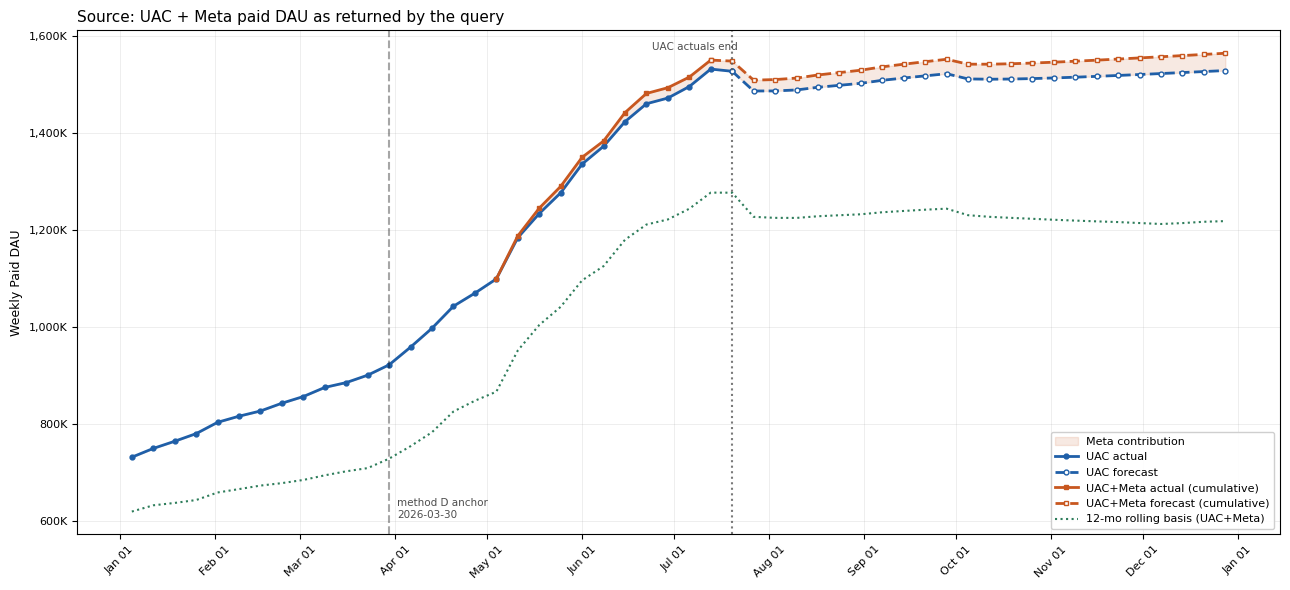

In [7]:
# [plot-source]
# The source series as the query presents it, plus what it replaced. Two things to read
# off this panel: the Meta band (the reason the query has four lines this cycle), and the
# step down where the marketing team's own actuals hand off to their forecast.

fig, ax = plt.subplots(figsize=(13, 6))

ax.fill_between(weekly.date, weekly.uac_raw, weekly.combined_total,
                color="#c8571f", alpha=0.13, label="Meta contribution")
ax.plot(weekly.date, weekly.uac_actual, color="#1f5fa8", lw=2.0, marker="o", ms=3.5,
        label="UAC actual")
ax.plot(weekly.date, weekly.uac_forecast, color="#1f5fa8", lw=2.0, ls="--", marker="o", ms=3.5,
        mfc="white", label="UAC forecast")
ax.plot(weekly.date, weekly.uac_meta_actual, color="#c8571f", lw=2.0, marker="s", ms=3.5,
        label="UAC+Meta actual (cumulative)")
ax.plot(weekly.date, weekly.uac_meta_forecast, color="#c8571f", lw=2.0, ls="--", marker="s", ms=3.5,
        mfc="white", label="UAC+Meta forecast (cumulative)")
ax.plot(weekly.date, weekly.combined_rolling, color="#2e7d5b", lw=1.5, ls=":",
        label="12-mo rolling basis (UAC+Meta)")

ax.axvline(ANCHOR_DATE, color="black", ls="--", alpha=0.35)
ax.annotate(f"method D anchor\n{ANCHOR_DATE.date()}", xy=(ANCHOR_DATE, ax.get_ylim()[0]),
            xytext=(6, 12), textcoords="offset points", fontsize=7.5, color="0.3")
ax.axvline(uac_actuals_through, color="0.35", ls=":", alpha=0.8)
ax.annotate("UAC actuals end", xy=(uac_actuals_through, ax.get_ylim()[1]),
            xytext=(-58, -14), textcoords="offset points", fontsize=7.5, color="0.3")

style_time_axis(ax, "Weekly Paid DAU", "Source: UAC + Meta paid DAU as returned by the query")
ax.legend(fontsize=8, loc="lower right", framealpha=0.93)
fig.tight_layout()
out = PLOTS / "marketing_source_uac_meta.png"
fig.savefig(out, dpi=140, bbox_inches="tight")
print(f"saved {out.relative_to(REPO)}")


saved data-official/2026-08/plots/marketing_method_d_candidates.png


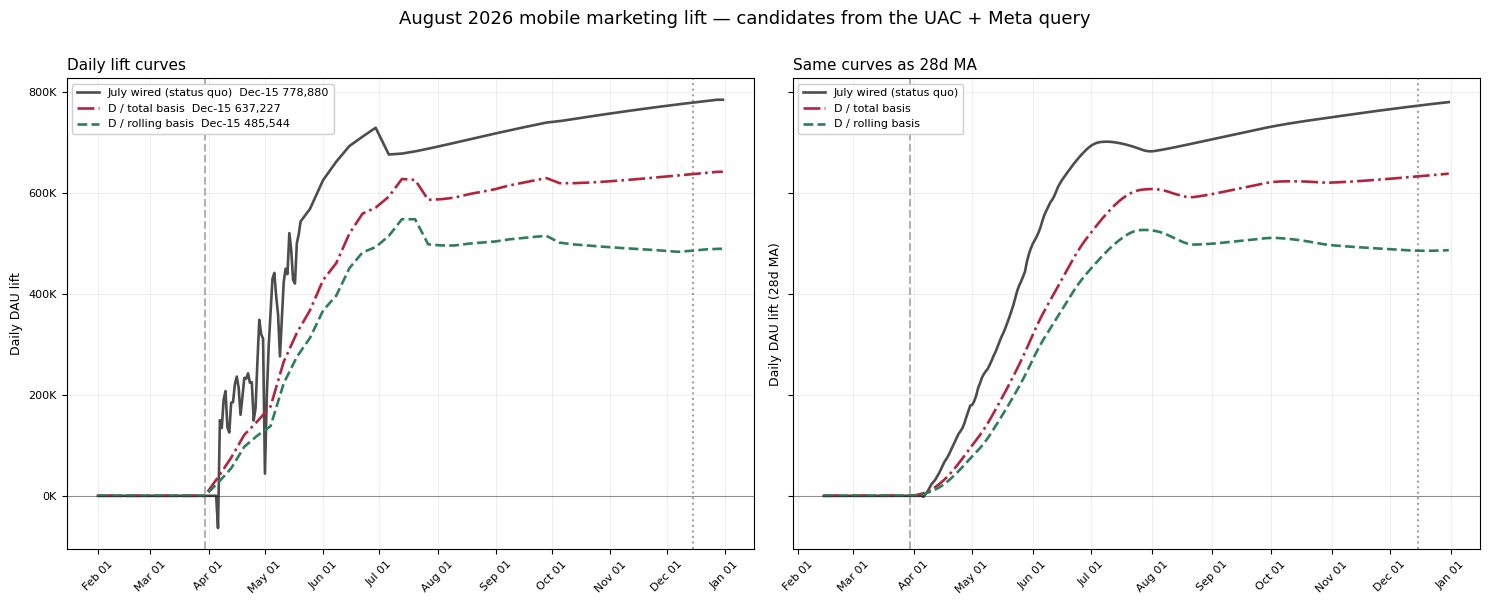

In [8]:
# [plot-methods]
# The two candidate curves against July's wired curve. Left: daily. Right: 28d MA, which is
# how the mobile forecast is presented to stakeholders.
#
# July's curve is spiky through April-June because its history is a raw daily empirical gap,
# day-of-week noise and all (including a one-day -63,955 spike at 2026-04-06). Both candidates
# are smooth by construction, coming from weekly source data interpolated to daily -- which
# matters, because this series is subtracted from training rows before Prophet sees them.

fig, (ax_daily, ax_ma) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

candidates = [
    ("July wired (status quo)", july_wired, "0.3", "-"),
    ("D / total basis", method_d["total"], "#b3243c", "-."),
    ("D / rolling basis", method_d["rolling"], "#2e7d5b", "--"),
]

for label, series, color, ls in candidates:
    ax_daily.plot(series.index, series.values, color=color, ls=ls, lw=1.9,
                  label=f"{label}  Dec-15 {series.loc[KPI_DATE]:,.0f}")
    ma = series.rolling(MA_WINDOW, min_periods=14).mean()
    ax_ma.plot(ma.index, ma.values, color=color, ls=ls, lw=1.9, label=label)

for ax in (ax_daily, ax_ma):
    ax.axvline(ANCHOR_DATE, color="black", ls="--", alpha=0.3)
    ax.axvline(KPI_DATE, color="0.4", ls=":", alpha=0.6)
    ax.axhline(0, color="black", lw=0.8, alpha=0.4)

style_time_axis(ax_daily, "Daily DAU lift", "Daily lift curves")
ax_daily.legend(fontsize=8, loc="upper left", framealpha=0.93)
style_time_axis(ax_ma, "Daily DAU lift (28d MA)", f"Same curves as {MA_WINDOW}d MA")
ax_ma.legend(fontsize=8, loc="upper left", framealpha=0.93)

fig.suptitle("August 2026 mobile marketing lift — candidates from the UAC + Meta query",
             fontsize=13, y=1.0)
fig.tight_layout()
out = PLOTS / "marketing_method_d_candidates.png"
fig.savefig(out, dpi=140, bbox_inches="tight")
print(f"saved {out.relative_to(REPO)}")


saved data-official/2026-08/plots/marketing_basis_decomposition.png


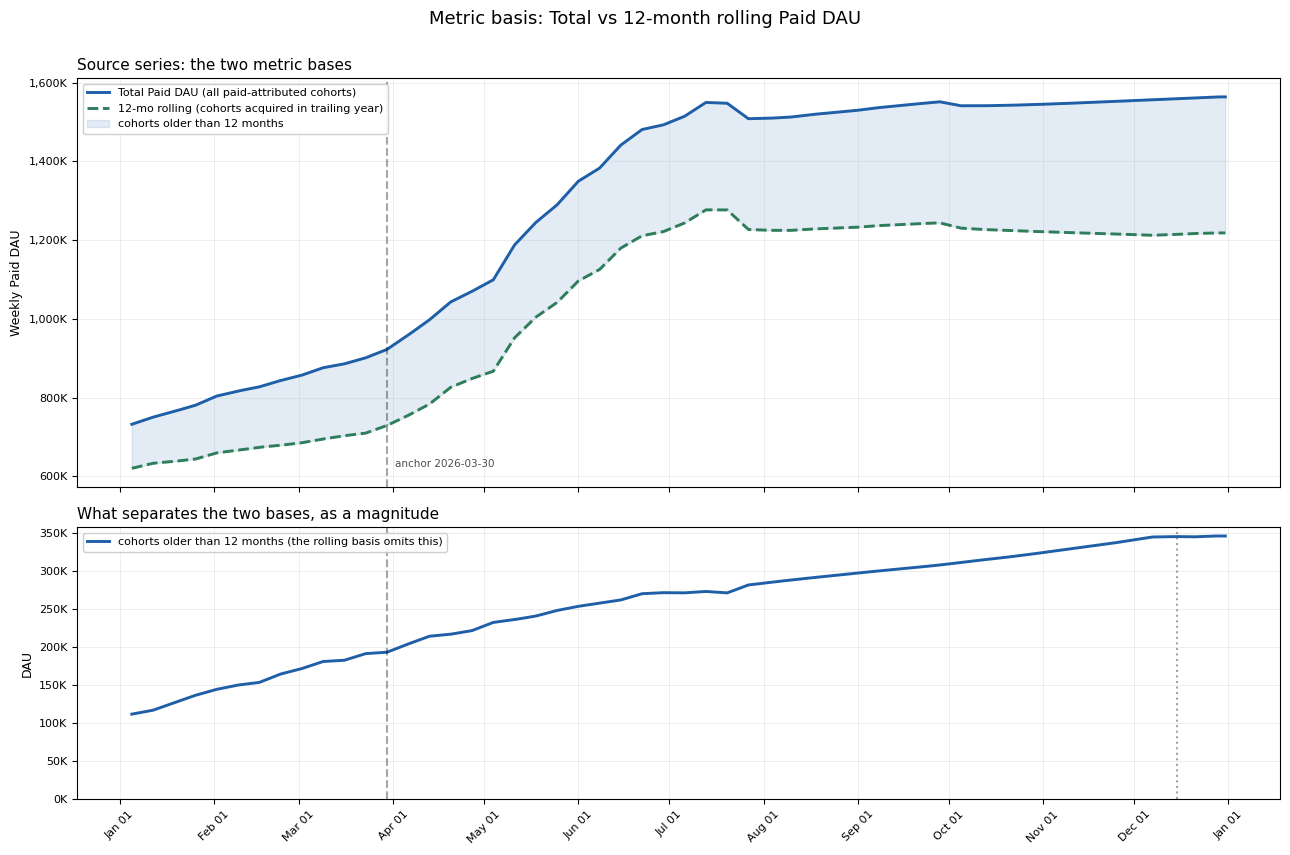

In [9]:
# [plot-basis-decomposition]
# Why the basis choice is not a matter of taste. Top: the two bases of the source series, with
# the band between them being paid DAU from cohorts older than 12 months. Bottom: that band as
# a magnitude -- it grows monotonically, from 193K at the anchor to 345K at Dec-15.
#
# Nothing happens to a user's DAU when they cross the 12-month attribution boundary; they
# simply stop being counted. So the rolling basis's extra shortfall is an accounting artifact.

fig, (ax_levels, ax_gap) = plt.subplots(2, 1, figsize=(13, 8.5), sharex=True,
                                        gridspec_kw={"height_ratios": [3, 2]})

ax_levels.plot(paid_daily["total"].index, paid_daily["total"].values, color="#1f5fa8", lw=2.1,
               label="Total Paid DAU (all paid-attributed cohorts)")
ax_levels.plot(paid_daily["rolling"].index, paid_daily["rolling"].values, color="#2e7d5b",
               lw=2.1, ls="--", label="12-mo rolling (cohorts acquired in trailing year)")
ax_levels.fill_between(paid_daily["total"].index, paid_daily["rolling"].values,
                       paid_daily["total"].values, color="#1f5fa8", alpha=0.12,
                       label="cohorts older than 12 months")

ax_levels.axvline(ANCHOR_DATE, color="black", ls="--", alpha=0.35)
ax_levels.annotate(f"anchor {ANCHOR_DATE.date()}", xy=(ANCHOR_DATE, ax_levels.get_ylim()[0]),
                   xytext=(6, 14), textcoords="offset points", fontsize=7.5, color="0.3")
style_time_axis(ax_levels, "Weekly Paid DAU", "Source series: the two metric bases")
ax_levels.legend(fontsize=8, loc="upper left", framealpha=0.93)

ax_gap.plot(aged_out.index, aged_out.values, color="#1f5fa8", lw=2.1,
            label="cohorts older than 12 months (the rolling basis omits this)")
ax_gap.axvline(ANCHOR_DATE, color="black", ls="--", alpha=0.35)
ax_gap.axvline(KPI_DATE, color="0.4", ls=":", alpha=0.6)
ax_gap.set_ylim(bottom=0)
style_time_axis(ax_gap, "DAU", "What separates the two bases, as a magnitude")
ax_gap.legend(fontsize=8, loc="upper left", framealpha=0.93)

fig.suptitle("Metric basis: Total vs 12-month rolling Paid DAU", fontsize=13, y=1.0)
fig.tight_layout()
out = PLOTS / "marketing_basis_decomposition.png"
fig.savefig(out, dpi=140, bbox_inches="tight")
print(f"saved {out.relative_to(REPO)}")


In [10]:
# [summary]
# Dec-15 readout. These are LIFT values (daily DAU added to the mobile forecast), not KPI
# values: the overlay is bidirectional, so it also changes what Prophet learns in training.
# The realised KPI effect comes from the test-apply run, not from this table.

fenix_at_training_end = float(actuals_fenix.loc[TRAINING_END])
wired_dec15 = float(july_wired.loc[KPI_DATE])

rows = []
for label, series in [
    ("July wired (status quo)", july_wired),
    ("D / total basis", method_d["total"]),
    ("D / rolling basis", method_d["rolling"]),
]:
    dec15 = float(series.loc[KPI_DATE])
    rows.append({
        "candidate": label,
        "Dec-15 lift": dec15,
        "vs wired": dec15 - wired_dec15,
        "EOY lift": float(series.loc[PARQUET_END]),
        "% Fenix DAU": 100 * dec15 / fenix_at_training_end,
    })

print(f"Fenix ex-IR DAU at training end ({TRAINING_END.date()}): {fenix_at_training_end:,.0f}\n")
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

print(f"""
Both candidates understate C (post-anchor cohort DAU, what the overlay contract specifies).
The query carries no cohort dimension, so the shortfall is not measurable from this source --
worth asking the marketing team to expose one.

Next step is the test-apply: subtract a curve from Fenix training rows, run mozaic, add it
back, and read the mobile Dec-15 KPI against the baseline in
data-official/2026-08/mobile_baseline_2026-07-28/ (which carries July's curve).

marketing.json still points at July's carried-forward curve. Nothing here is wired.""")


Fenix ex-IR DAU at training end (2026-07-27): 12,557,560

              candidate  Dec-15 lift   vs wired  EOY lift  % Fenix DAU
July wired (status quo)    778,879.7        0.0 784,476.3          6.2
        D / total basis    637,226.7 -141,653.0 641,699.8          5.1
      D / rolling basis    485,543.7 -293,336.0 489,231.7          3.9

Both candidates understate C (post-anchor cohort DAU, what the overlay contract specifies).
The query carries no cohort dimension, so the shortfall is not measurable from this source --
worth asking the marketing team to expose one.

Next step is the test-apply: subtract a curve from Fenix training rows, run mozaic, add it
back, and read the mobile Dec-15 KPI against the baseline in
data-official/2026-08/mobile_baseline_2026-07-28/ (which carries July's curve).

marketing.json still points at July's carried-forward curve. Nothing here is wired.


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


saved data-official/2026-08/plots/marketing_testapply_kpi.png

date            July curve   Total-basis        delta
2026-08-25      17,077,819    16,959,065     -118,753
2026-09-15      17,293,921    17,173,514     -120,407
2026-10-15      17,517,608    17,413,011     -104,597
2026-11-15      17,696,666    17,597,546      -99,120
2026-12-15      17,951,769    17,891,894      -59,875

Training rows unchanged by the swap: max |delta| 3.70 DAU
Absolutes are PRE-headwind, so they do not match the cycle's published Mobile Dec-15 (17,924,607, which has adj-h applied). The delta is the meaningful number.


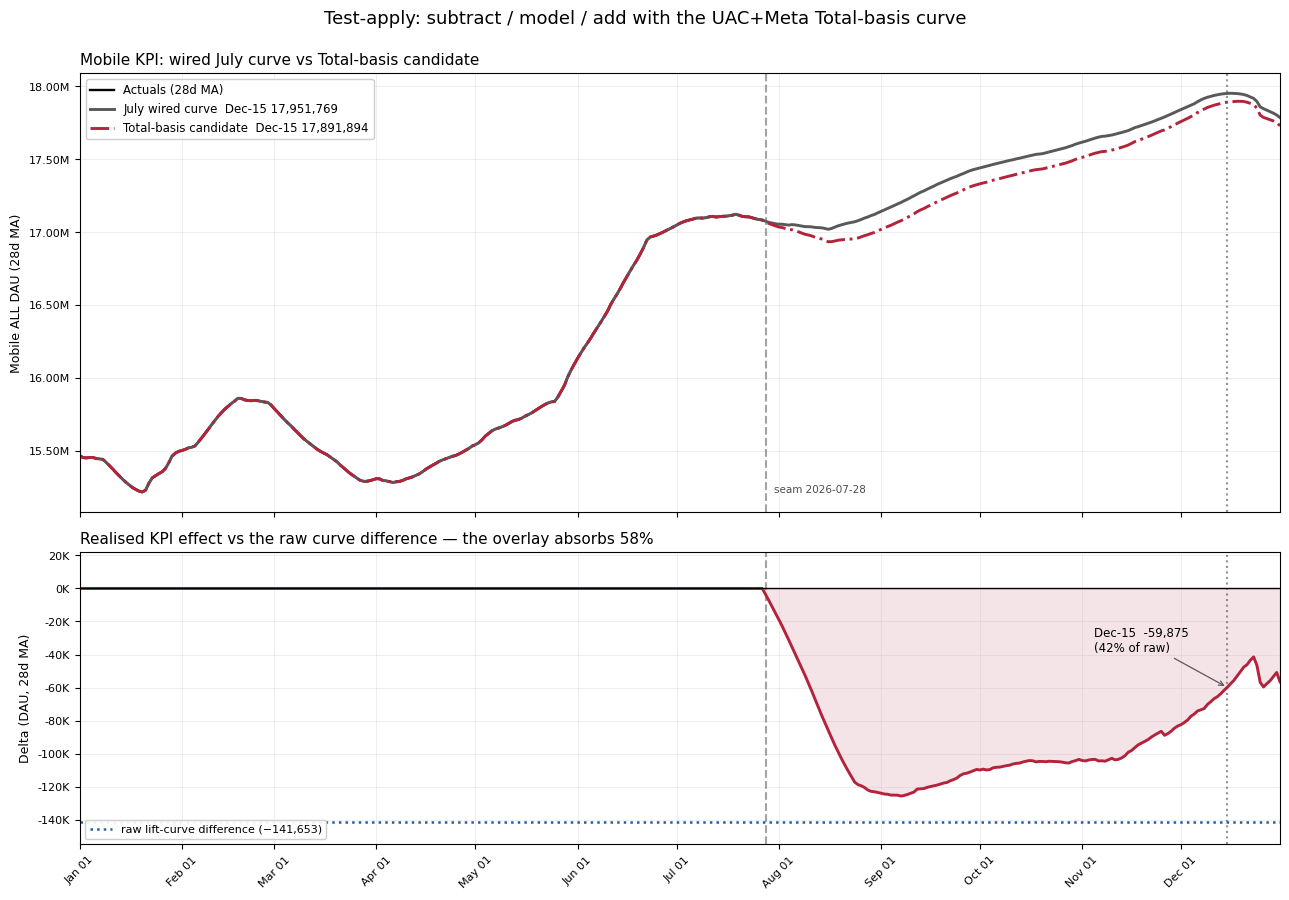

In [11]:
# [plot-testapply]
# The test-apply result: what the subtract/model/add path actually does to the mobile KPI when
# the wired July curve is swapped for the Total-basis candidate.
#
# The headline is the SECOND panel. The two lift curves differ by -141,653 at Dec-15, but the
# realised KPI difference is only -59,875 -- the bidirectional overlay absorbs 58% of it,
# because a smaller subtraction from training leaves Prophet a higher organic trend that
# partly offsets the smaller add-back. The offset compounds with horizon, so the gap NARROWS
# from -119K in August to -60K by December.
#
# NOTE: the candidate forecast currently lives under tmp/ (throwaway). Promote it into
# data-official/2026-08/marketing/ if this comparison should stay reproducible.

from mozaic_daily.seam_ma import display_ma

BASELINE_FORECAST = (REPO / "data-official/2026-08/mobile_baseline_2026-07-28"
                     / "cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6_sps0.1"
                     / "mozaic_daily_forecast.2026-07-28.gm-D.adj-m.parquet")
TESTAPPLY_FORECAST = REPO / "tmp/mktg_testapply_total/mozaic_daily_forecast.2026-07-28.gm-D.parquet"
SEAM = pd.Timestamp("2026-07-28")


def mobile_all_rollup(path, data_type=None):
    """ALL-MOBILE / ALL-country DAU series from a glean_mobile forecast parquet."""
    df = pd.read_parquet(path)
    rollup = df[(df["data_source"] == "glean_mobile") & (df["country"] == "ALL")
                & (df["app_name"] == "ALL MOBILE") & (df["segment"] == "{}")].copy()
    if data_type is not None:
        rollup = rollup[rollup["data_type"] == data_type]
    rollup["target_date"] = pd.to_datetime(rollup["target_date"])
    return rollup.set_index("target_date").sort_index()["dau"]


baseline = mobile_all_rollup(BASELINE_FORECAST)
testapply = mobile_all_rollup(TESTAPPLY_FORECAST)
# Training rows are actuals (verified by scripts/verify_training_rows_are_actuals.py), so they
# stand in for a BQ actuals query here.
actuals = mobile_all_rollup(BASELINE_FORECAST, data_type="training")

baseline_ma = display_ma(baseline.index, baseline, SEAM)
testapply_ma = display_ma(testapply.index, testapply, SEAM)
actuals_ma = actuals.rolling(MA_WINDOW, min_periods=14).mean()
delta_ma = (testapply_ma - baseline_ma).dropna()

# Slice to the display window BEFORE plotting. These series run back to 2020, and matplotlib
# autoscales y over all supplied data regardless of xlim -- which would drag the axis down to
# ~8M and render a ~60-120K difference on a ~18M series completely invisible.
DISPLAY_LO, DISPLAY_HI = pd.Timestamp("2026-01-01"), pd.Timestamp("2026-12-31")


def for_display(series):
    return series.loc[DISPLAY_LO:DISPLAY_HI]


fig, (ax_kpi, ax_delta) = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                                       gridspec_kw={"height_ratios": [3, 2]})

ax_kpi.plot(for_display(actuals_ma).index, for_display(actuals_ma).values, color="black",
            lw=1.7, label="Actuals (28d MA)")
ax_kpi.plot(for_display(baseline_ma).index, for_display(baseline_ma).values, color="0.35",
            lw=2.1, ls="-", label=f"July wired curve  Dec-15 {baseline_ma.loc[KPI_DATE]:,.0f}")
ax_kpi.plot(for_display(testapply_ma).index, for_display(testapply_ma).values, color="#b3243c",
            lw=2.1, ls="-.", label=f"Total-basis candidate  Dec-15 {testapply_ma.loc[KPI_DATE]:,.0f}")

for ax in (ax_kpi, ax_delta):
    ax.axvline(SEAM, color="0.4", ls="--", alpha=0.6)
    ax.axvline(KPI_DATE, color="0.4", ls=":", alpha=0.7)
ax_kpi.annotate(f"seam {SEAM.date()}", xy=(SEAM, ax_kpi.get_ylim()[0]), xytext=(6, 14),
                textcoords="offset points", fontsize=7.5, color="0.3")

# Range is ~16.3M-18.0M in ~0.2M steps, so 2dp in millions keeps adjacent ticks distinct.
style_time_axis(ax_kpi, "Mobile ALL DAU (28d MA)",
                "Mobile KPI: wired July curve vs Total-basis candidate",
                yfmt=fmt_millions_2dp)
ax_kpi.legend(fontsize=8.5, loc="upper left", framealpha=0.93)
ax_kpi.set_xlim(pd.Timestamp("2026-01-01"), pd.Timestamp("2026-12-31"))

delta_display = for_display(delta_ma)
ax_delta.plot(delta_display.index, delta_display.values, color="#b3243c", lw=2.1)
ax_delta.fill_between(delta_display.index, delta_display.values, 0, color="#b3243c", alpha=0.12)
ax_delta.axhline(0, color="black", lw=1.0)
ax_delta.axhline(-141_653, color="#1f5fa8", ls=":", lw=1.8,
                 label="raw lift-curve difference (−141,653)")
ax_delta.set_ylim(-155_000, 22_000)
ax_delta.annotate(f"Dec-15  {delta_ma.loc[KPI_DATE]:+,.0f}\n({delta_ma.loc[KPI_DATE] / -141_653:.0%} of raw)",
                  xy=(KPI_DATE, delta_ma.loc[KPI_DATE]), xytext=(-96, 26),
                  textcoords="offset points", fontsize=8.5,
                  arrowprops=dict(arrowstyle="->", color="0.35", lw=0.9))
style_time_axis(ax_delta, "Delta (DAU, 28d MA)",
                "Realised KPI effect vs the raw curve difference — the overlay absorbs 58%")
ax_delta.legend(fontsize=8, loc="lower left", framealpha=0.93)

fig.suptitle("Test-apply: subtract / model / add with the UAC+Meta Total-basis curve",
             fontsize=13, y=0.995)
fig.tight_layout()
out = PLOTS / "marketing_testapply_kpi.png"
fig.savefig(out, dpi=140, bbox_inches="tight")
print(f"saved {out.relative_to(REPO)}\n")

print(f"{'date':<12}{'July curve':>14}{'Total-basis':>14}{'delta':>13}")
for d in ["2026-08-25", "2026-09-15", "2026-10-15", "2026-11-15", "2026-12-15"]:
    t = pd.Timestamp(d)
    print(f"{d:<12}{baseline_ma[t]:>14,.0f}{testapply_ma[t]:>14,.0f}{testapply_ma[t] - baseline_ma[t]:>+13,.0f}")
print(f"\nTraining rows unchanged by the swap: max |delta| "
      f"{(baseline.loc['2026-06-01':'2026-07-27'] - testapply.loc['2026-06-01':'2026-07-27']).abs().max():,.2f} DAU")
print("Absolutes are PRE-headwind, so they do not match the cycle's published Mobile Dec-15 "
      "(17,924,607, which has adj-h applied). The delta is the meaningful number.")


saved data-official/2026-08/plots/marketing_july_vs_august_curves.png

             July delivered  August delivered    delta
target_date                                           
2026-04-06          -63,955            36,488  100,444
2026-05-20          543,360           335,390 -207,970
2026-06-28          726,490           569,040 -157,450
2026-07-27          687,452           586,282 -101,170
2026-09-15          729,219           619,897 -109,321
2026-12-15          778,880           637,227 -141,653
2026-12-31          784,476           641,700 -142,776


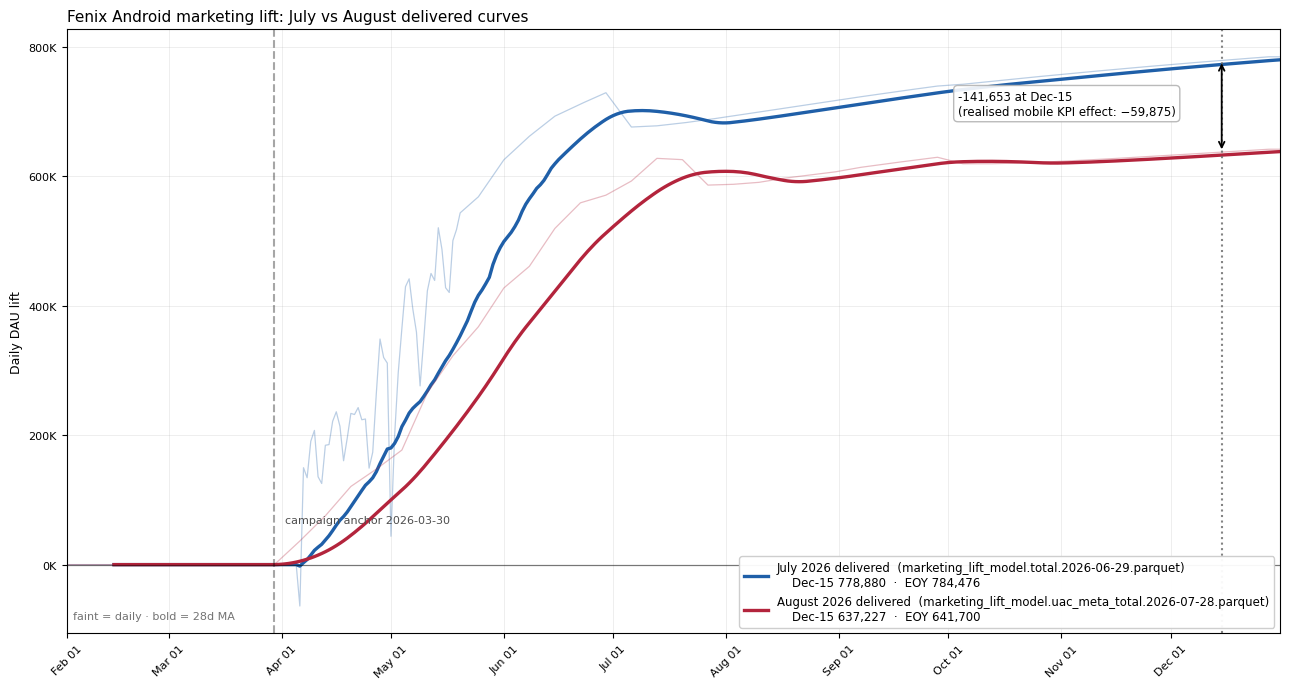

In [12]:
# [plot-july-vs-august]
# The two marketing lift curves on one set of axes: what July shipped vs what August ships.
# Both are read from the delivered parquets rather than recomputed, so this shows the artifacts
# the specs actually point at.
#
# Daily series are drawn faint and the 28d MAs bold, same colour per cycle. July's daily curve is
# visibly ragged because its history is a raw empirical gap carrying day-of-week noise; August's is
# smooth, coming from weekly source data interpolated to daily. That matters beyond cosmetics --
# this series is subtracted from Fenix training rows before Prophet sees them.

JULY_CURVE = REPO / "data-official/2026-07/marketing/marketing_lift_model.total.2026-06-29.parquet"
AUGUST_CURVE = HERE / "marketing_lift_model.uac_meta_total.2026-07-28.parquet"


def load_lift_curve(path):
    series = pd.read_parquet(path)["marketing_lift_daily"]
    series.index = pd.DatetimeIndex(series.index)
    return series.sort_index()


july_curve = load_lift_curve(JULY_CURVE)
august_curve = load_lift_curve(AUGUST_CURVE)

fig, ax = plt.subplots(figsize=(13, 7))

for label, series, color in [
    (f"July 2026 delivered  ({JULY_CURVE.name})", july_curve, "#1f5fa8"),
    (f"August 2026 delivered  ({AUGUST_CURVE.name})", august_curve, "#b3243c"),
]:
    ax.plot(series.index, series.values, color=color, lw=0.9, alpha=0.30)
    ma = series.rolling(MA_WINDOW, min_periods=14).mean()
    ax.plot(ma.index, ma.values, color=color, lw=2.4,
            label=f"{label}\n    Dec-15 {series.loc[KPI_DATE]:,.0f}  ·  EOY {series.loc[PARQUET_END]:,.0f}")

ax.axvline(ANCHOR_DATE, color="black", ls="--", alpha=0.35)
ax.annotate(f"campaign anchor {ANCHOR_DATE.date()}", xy=(ANCHOR_DATE, 0), xytext=(8, 30),
            textcoords="offset points", fontsize=8, color="0.3")
ax.axvline(KPI_DATE, color="0.4", ls=":", alpha=0.8)
ax.axhline(0, color="black", lw=0.9, alpha=0.5)

# Annotate the Dec-15 gap between the two curves.
jul_dec15, aug_dec15 = float(july_curve.loc[KPI_DATE]), float(august_curve.loc[KPI_DATE])
ax.annotate("", xy=(KPI_DATE, jul_dec15), xytext=(KPI_DATE, aug_dec15),
            arrowprops=dict(arrowstyle="<->", color="black", lw=1.3))
ax.annotate(f"{aug_dec15 - jul_dec15:+,.0f} at Dec-15\n(realised mobile KPI effect: −59,875)",
            xy=(KPI_DATE, (jul_dec15 + aug_dec15) / 2), xytext=(-190, -6),
            textcoords="offset points", fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.7", alpha=0.9))

style_time_axis(ax, "Daily DAU lift", "Fenix Android marketing lift: July vs August delivered curves")
ax.set_xlim(PARQUET_START, PARQUET_END)
# Lower right: the only region both curves and the Dec-15 callout leave clear.
ax.legend(fontsize=8.5, loc="lower right", framealpha=0.95)
ax.text(0.005, 0.02, "faint = daily · bold = 28d MA", transform=ax.transAxes,
        ha="left", va="bottom", fontsize=8, color="0.45")

fig.tight_layout()
out = PLOTS / "marketing_july_vs_august_curves.png"
fig.savefig(out, dpi=140, bbox_inches="tight")
print(f"saved {out.relative_to(REPO)}\n")

comparison = pd.DataFrame({"July delivered": july_curve, "August delivered": august_curve})
comparison["delta"] = comparison["August delivered"] - comparison["July delivered"]
print(comparison.loc[["2026-04-06", "2026-05-20", "2026-06-28", "2026-07-27",
                      "2026-09-15", "2026-12-15", "2026-12-31"]]
      .to_string(float_format=lambda v: f"{v:,.0f}"))
